## Vision Transformer from Scratch

In [1]:
!pip install einops

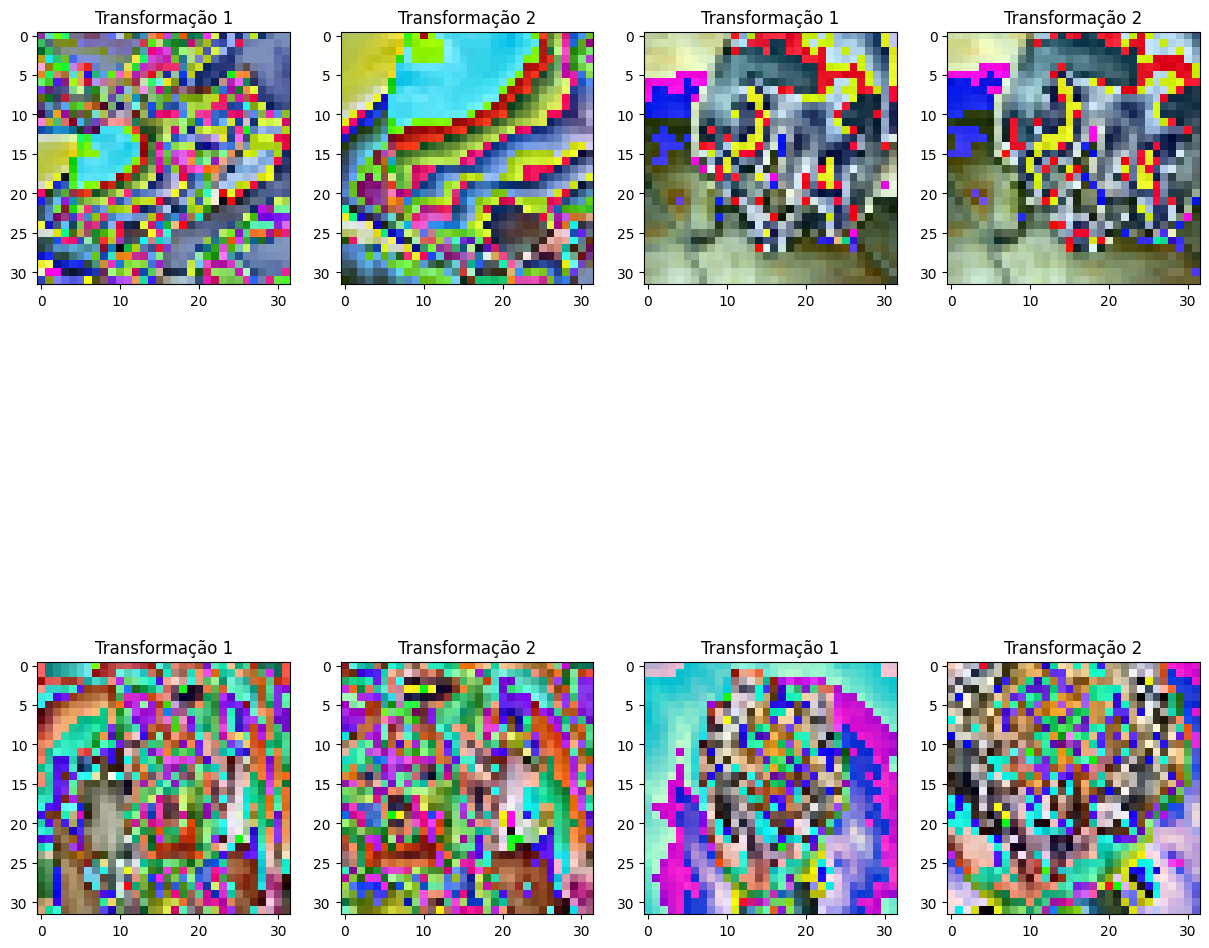

In [ ]:
#Image patching

import torch
from torchvision.datasets import OxfordIIITPet
import matplotlib.pyplot as plt
from random import random
from torchvision.transforms import ToTensor, Resize
from torchvision.transforms.functional import to_pil_image
from torchvision import transforms, datasets

# from util import DoubleTransform

class DoubleTransform:
    def __init__(self, base_transform1, base_transform2):
        self.base_transform1 = base_transform1
        self.base_transform2 = base_transform2

    def __call__(self, x):
        return self.base_transform1(x), self.base_transform2(x)
    
normalize = transforms.Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.2010))

train_transform = DoubleTransform(
                    transforms.Compose([
                    transforms.Resize([32, 32]),
                    transforms.ToTensor(),
                    normalize,
                    ]),
                    transforms.Compose([
                    transforms.RandomResizedCrop(size=32, scale=(0.2, 1.)),
                    transforms.RandomHorizontalFlip(),
                    transforms.ToTensor(),
                    normalize])
                    )
                      

# def show_images(images, num_samples=20, cols=4):
#     """Plot a set of images from the dataset.

#     Args:
#         images (_type_): _description_
#         num_samples (int, optional): _description_. Defaults to 20.
#         cols (int, optional): _description_. Defaults to 4.
#     """    

#     plt.figure(figsize=(15, 15))
#     idx=int(len(dataset)/num_samples)
#     print(images)
#     for i, img in enumerate(images):
#         if i % idx == 0:
#             plt.subplot(int(num_samples/cols) + 1, cols, int(i/idx) + 1)
#             plt.imshow(to_pil_image(img[0]))

# Função para exibir imagens

def show_images(images, num_samples=4, cols=4):
    """Exibe um conjunto de imagens."""
    plt.figure(figsize=(15, 15))
    idx = max(1, int(len(images) / num_samples))
    for i, (img_pair, _) in enumerate(images):
        if i % idx == 0 and i // idx < num_samples:
            img1, img2 = img_pair  # Obtém as duas visualizações da transformação
            
            plt.subplot(int(num_samples / cols) + 1, cols, i // idx * 2 + 1)
            plt.imshow(to_pil_image(img1))
            plt.title("Transformação 1")

            plt.subplot(int(num_samples / cols) + 1, cols, i // idx * 2 + 2)
            plt.imshow(to_pil_image(img2))
            plt.title("Transformação 2")
    plt.show()



dataset = OxfordIIITPet(root=".", transform=train_transform, download=True)

show_images(dataset)

## Patch Images

In [2]:
from torch import nn
from einops.layers.torch import Rearrange
from torch import Tensor

In [3]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels: int = 3, patch_size: int = 8, emb_size: int = 128):
        
        self.patch_size = patch_size

        super().__init__()

        self.projection = nn.Sequential(
            # break the image into chunks (n_patches, patch_size, patch_size)
            Rearrange('b c (h s1) (w s2) -> b (h w) (s1 s2 c)', s1=patch_size, s2=patch_size),
            nn.Linear(patch_size * patch_size * in_channels, emb_size)
        )

    def forward(self, x: Tensor) -> Tensor:
        x = self.projection(x)
        return x

In [4]:
sample_datapoint = dataset[0][0]  # Apenas a imagem
if not isinstance(sample_datapoint, torch.Tensor):
    sample_datapoint = torch.tensor(sample_datapoint)  # Converte se necessário
sample_datapoint = torch.unsqueeze(sample_datapoint, 0)  # Adiciona uma dimensão

print("Shape inicial: ", sample_datapoint.shape)

# Aplicando o PatchEmbedding
embedding = PatchEmbedding()(sample_datapoint)
print("Patches shapes final: ", embedding.shape)


ValueError: only one element tensors can be converted to Python scalars

## Model

CLS Token:
- No contexto do Vision Transformer, o CLS token é aplicado de forma semelhante. No ViT, uma imagem é dividida em patches (fragmentos) que são então linearizados e embutidos. Junto com esses embutidos de patches, é adicionado um token especial, o CLS token, no início da sequência de patches. O ViT então processa essa sequência de tokens, incluindo o CLS token, através de camadas de transformadores.

- Após o processamento, o vetor de saída correspondente ao CLS token é usado como uma representação agregada da imagem inteira e é passado para a camada de classificação final para realizar a tarefa específica (por exemplo, classificação de imagens).

- Em resumo, o CLS token no Vision Transformer serve como um ponto de agregação que resume a informação da imagem inteira para facilitar tarefas de classificação.


Positional Embedding:
- É um mecanismo utilizado para incorporar informações sobre a posição dos patches de imagem na sequência de entrada para o modelo transformer.

In [5]:
from einops import rearrange

class Attention(nn.Module):
    def __init__(self, dim, n_heads, dropout):
        super().__init__()
        self.n_heads = n_heads
        self.attention = nn.MultiheadAttention(embed_dim=dim,
                                               num_heads=n_heads,
                                               dropout=dropout)
        self.q = torch.nn.Linear(dim, dim)
        self.k = torch.nn.Linear(dim, dim)
        self.v = torch.nn.Linear(dim, dim)
    
    def forward(self, x):
        q = self.q(x)
        k = self.k(x)
        v = self.v(x)

        attention_output, attention_output_weights = self.attention(q, k, v)
        return attention_output

In [6]:
Attention(dim=128, n_heads=4, dropout=0.)(torch.ones((1, 5, 128))).shape

torch.Size([1, 5, 128])

In [7]:
class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fn = fn

    def forward(self, x, **kwargs):
        return self.fn(self.norm(x), **kwargs)

In [8]:
norm = PreNorm(128, Attention(dim=128, n_heads=4, dropout=0.))
norm(torch.ones((1, 5, 128))).shape

torch.Size([1, 5, 128])

In [9]:
class FeedForward(nn.Sequential):
    def __init__(self, dim, hidden_dim, dropout = 0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )

In [10]:
ff = FeedForward(dim=128, hidden_dim=256)
ff(torch.ones((1, 5, 128))).shape

torch.Size([1, 5, 128])

In [11]:
class ResidualAdd(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, **kwargs):
        res = x
        x = self.fn(x, **kwargs)
        x += res
        return x 

In [12]:
residual_attention = ResidualAdd(Attention(dim=128, n_heads=4, dropout=0.))
residual_attention(torch.ones((1, 5, 128))).shape

torch.Size([1, 5, 128])

- Not all parameters are like in the original implementation
- Some dropouts and norms are missing
- ToDo: Checar a implementação do google research no github

In [13]:
from einops import repeat

class ViT(nn.Module):
    def __init__(self, 
                 channels: int = 3,
                 image_size: int = 144,
                 patch_size: int = 8,
                 emb_size: int = 32,
                 n_layers: int = 4,
                 out_dim: int = 37,
                 dropout: float = 0.1,
                 n_heads: int = 2):
        super(ViT, self).__init__()

        #Atributos
        self.channels = channels
        self.height = image_size
        self.widht = image_size
        self.patch_size = patch_size
        self.n_layers = n_layers

        #Patching
        self.patch_embedding = PatchEmbedding(in_channels=channels, 
                                              patch_size=patch_size, 
                                              emb_size=emb_size)
            
        #Learnable params
        num_patches = (image_size // patch_size) ** 2
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, emb_size))
        self.cls_token = nn.Parameter(torch.rand(1, 1, emb_size))

        #Encoder
        self.layers = nn.ModuleList([])
        for _ in range(n_layers):
            transformer_block = nn.Sequential(
                ResidualAdd(PreNorm(emb_size, Attention(dim=emb_size, n_heads=n_heads, dropout=dropout))),
                ResidualAdd(PreNorm(emb_size, FeedForward(dim=emb_size, hidden_dim=emb_size, dropout=dropout)))
            )
            self.layers.append(transformer_block)
        
        #Classification head
        self.head = nn.Sequential(
            nn.LayerNorm(emb_size),
            nn.Linear(emb_size, out_dim)
        )


    def forward(self, image):

        #Get patch embedding vectos
        x = self.patch_embedding(image)
        b, n, _ = x.shape

        #Add class (cls) token and position embedding
        cls_tokens = repeat(self.cls_token, '1 1 d -> b 1 d', b=b)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embedding[:, :(n + 1)]
        
        #Transformer layers / pass through the layers
        for i in range(self.n_layers):
            x = self.layers[i](x)
        
        #Ouput based on the classification token
        return self.head(x[:, 0, :])

In [14]:
model = ViT()
print(model)
model(torch.ones((1, 3, 144, 144)))

ViT(
  (patch_embedding): PatchEmbedding(
    (projection): Sequential(
      (0): Rearrange('b c (h s1) (w s2) -> b (h w) (s1 s2 c)', s1=8, s2=8)
      (1): Linear(in_features=192, out_features=32, bias=True)
    )
  )
  (layers): ModuleList(
    (0-3): 4 x Sequential(
      (0): ResidualAdd(
        (fn): PreNorm(
          (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
          (fn): Attention(
            (attention): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
            )
            (q): Linear(in_features=32, out_features=32, bias=True)
            (k): Linear(in_features=32, out_features=32, bias=True)
            (v): Linear(in_features=32, out_features=32, bias=True)
          )
        )
      )
      (1): ResidualAdd(
        (fn): PreNorm(
          (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
          (fn): FeedForward(
            (net): Sequential(
           

tensor([[ 0.4045,  0.4151,  0.8537, -0.7029,  0.2612,  0.1764,  0.4744,  0.3492,
         -0.7411,  0.4348, -0.6523,  0.7646, -0.3089, -0.0783,  0.5765, -1.0435,
         -0.3593,  0.6291,  0.2251, -0.9574,  0.1846, -0.9025,  0.0647,  0.2683,
          0.6405, -0.4046, -1.0765, -0.9652, -0.0348, -0.9345, -0.7418, -0.8409,
          0.3368,  0.4245, -0.0929, -0.6570, -0.9964]],
       grad_fn=<AddmmBackward0>)

## Training

In [15]:
from torch.utils.data import DataLoader
from torch.utils.data import random_split

train_split = int(0.8 * len(dataset))
train, test = random_split(dataset, [train_split, len(dataset) - train_split])

In [16]:
train_dataloader = DataLoader(train, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test, batch_size=32, shuffle=True)

In [ ]:
import torch.optim as optim
import numpy as np

device = "cuda"
model = ViT().to(device)
#optimizer = optim.AdamW(model.parameters(), lr=0.001)
#criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

from losses import SupConLoss
criterion = SupConLoss(temperature=0.07)


for epoch in range(100):
    epoch_losses = []
    model.train()
    for idx, (image_aug_tuple, labels) in enumerate(train_dataloader):
        
    for step, (inputs, labels) in enumerate(train_dataloader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())

    if epoch % 5 == 0:
        print(f">>> Epoch {epoch} train loss: ", np.mean(epoch_losses))
        epoch_losses = []
        # Something was strange when using this?
        # model.eval()
        for step, (inputs, labels) in enumerate(test_dataloader):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            epoch_losses.append(loss.item())
        print(f">>> Epoch {epoch} test loss: ", np.mean(epoch_losses))

AttributeError: 'list' object has no attribute 'to'

In [ ]:
inputs, labels = next(iter(test_dataloader))
inputs, labels = inputs.to(device), labels.to(device)
outputs = model(inputs)

print("Predicted classes", outputs.argmax(-1))
print("Actual classes", labels)